#### [260706]_MNIST <hr>
- train.csv 6만개 -> 2만개
- test.csv  1만개 -> 5천개
- 짝수와 홀수 숫자 분류
    - 타겟 새롭게 설정 : even, odd
- 층(layer) 수에 따른 성능 차이
    -> 1,3,5,7,9
- 픽셀값의 스케일링에 따른 성능 차이
    -> X, 0 ~ 1
- 모델 클래스, 데이터셋 클래스
- 학습, 검증  사용자정의 함수
- 학습 후 시각화 
- ----------------------------------------

In [9]:
import pandas as pd, numpy as np, torch, sys, matplotlib.pyplot as plt, koreanize_matplotlib
sys.path.append('./dl_func.py')
from dl_func import *

import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from torch.optim import Adam
from torch.nn import CrossEntropyLoss

In [10]:
class EvenOddClassifier(nn.Module):
    def __init__(self, hidden_sizes):
        super().__init__()
        sizes = [784] + list(hidden_sizes)
        self.hidden_layers = nn.ModuleList(
            [nn.Linear(sizes[i], sizes[i+1]) for i in range(len(sizes)-1)]
        )
        self.out_layer = nn.Linear(sizes[-1], 2)

    def forward(self, data):
        out = data
        for layer in self.hidden_layers:
            out = F.relu(layer(out))
        return self.out_layer(out)

class EvenOddDataset(Dataset):
    def __init__(self, feature, target, scale=False):
        super().__init__()
        self.feature = feature.values.astype(np.float32)
        if scale:
            self.feature = self.feature / 255.0
        self.target = target.values
        self.length = len(feature)

    # 샘플 수 반환 메서드
    def __len__(self):
        return self.length

    # 인덱스에 해당하는 피쳐와 타겟 텐서 반환 메서드
    def __getitem__(self, index):
        feature = torch.FloatTensor(self.feature[index])
        target = torch.tensor(self.target[index], dtype=torch.long)
        return feature, target

In [11]:
# 데이터 준비 및 확인
train_df = pd.read_csv('../../[8] 머신러닝/Data/Numbers/mnist_train.csv', header=None)
test_df = pd.read_csv('../../[8] 머신러닝/Data/Numbers/mnist_test.csv', header=None)

# 6만개 -> 2만개, 1만개 -> 5천개
train_df = train_df[:20000]
test_df = test_df[:5000]

In [12]:
feature = train_df[train_df.columns[1:]]
target_digit = train_df[train_df.columns[0]]

target = (target_digit % 2 != 0).astype(int)
print(feature.shape, target.shape)
print(target.value_counts())

feature_test = test_df[test_df.columns[1:]]
target_digit_test = test_df[test_df.columns[0]]
target_test = (target_digit_test % 2 != 0).astype(int)
print(feature_test.shape, target_test.shape)

(20000, 784) (20000,)
0
1    10239
0     9761
Name: count, dtype: int64
(5000, 784) (5000,)


**[1]학습준비**
- 클래스 준비 : 모델, 데이터셋
- 학습 설정 : 학습 횟수, 배치 크기, 러닝 레이트, 이터레이션 개수
- 데이터셋 준비 : 학습용, 테스트용, 검증용

In [13]:
# 학습용 : 검증용 = 80 :20
x_train, x_valid, y_train, y_valid = train_test_split(feature, target, test_size=0.2, random_state=42, stratify=target)
print(f'{x_train.shape}, {y_train.shape}')
print(f'{x_valid.shape}, {y_valid.shape}')

(16000, 784), (16000,)
(4000, 784), (4000,)


In [ ]:
# 학습 관련 설정
# => 학습 횟수 : epoch
epochs = 15

# => 학습량 : 1번 학습 후 W,B 업데이트
bs = 500

# => W,B 값 보정 정도
LR = 0.001

DIVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

layer_configs = {
    1: [128],
    3: [256, 128, 64],
    5: [350, 174, 86, 42, 20],
    7: [350, 174, 86, 42, 20, 10, 8],
    9: [350, 174, 86, 42, 20, 10, 8, 4, 2],
}

scale_options = {
    'RAW(0~255)': False,
    'Scaled(0~1)': True,
}

**[2] 학습 진행**
- epoch 단위 loss 저장 : 배치단위 loss 모두 저장 후 평균계산
- epoch 증가 될수록 loss 감소되어야 함 
- 학습용과 검증용 비교 진행 => 과대적합 체크 및 학습 중단 고려

In [15]:
import datetime

results = {}

for n_layers, hidden_sizes in layer_configs.items():
    for scale_label, scale_flag in scale_options.items():
        print(f"\n===== 은닉층 {n_layers}개 / {scale_label} =====")

        trainDS = EvenOddDataset(x_train, y_train, scale=scale_flag)
        validDS = EvenOddDataset(x_valid, y_valid, scale=scale_flag)
        trainDL = DataLoader(trainDS, batch_size=bs, shuffle=True)
        validDL = DataLoader(validDS, batch_size=bs)

        model  = EvenOddClassifier(hidden_sizes).to(DIVICE)
        adam   = Adam(model.parameters(), lr=LR)
        lossFN = CrossEntropyLoss()

        lossEpoch, scoreEpoch = {'Train':[], 'Valid':[]}, {'Train':[], 'Valid':[]}
        start = datetime.datetime.now()

        for epo in range(epochs):
            train_loss, train_acc = training(model, trainDL, lossFN, adam, len(x_train), DIVICE)
            valid_loss, valid_acc = evaluating(model, validDL, lossFN, len(x_valid), DIVICE)

            lossEpoch['Train'].append(train_loss); scoreEpoch['Train'].append(train_acc)
            lossEpoch['Valid'].append(valid_loss); scoreEpoch['Valid'].append(valid_acc)

        elapsed = datetime.datetime.now() - start
        print(f"[은닉층 {n_layers}개/{scale_label}] 최종 VALID LOSS:{lossEpoch['Valid'][-1]:.5f}"
              f"  ACC:{scoreEpoch['Valid'][-1]:.5f}  TIME:{str(elapsed).split('.')[0]}")

        results[(n_layers, scale_label)] = {
            'lossEpoch': lossEpoch,
            'scoreEpoch': scoreEpoch,
            'final_valid_loss': lossEpoch['Valid'][-1],
            'final_valid_acc': scoreEpoch['Valid'][-1],
        }


===== 은닉층 1개 / RAW(0~255) =====
[은닉층 1개/RAW(0~255)] 최종 VALID LOSS:0.09300  ACC:0.97625  TIME:0:00:11

===== 은닉층 1개 / Scaled(0~1) =====
[은닉층 1개/Scaled(0~1)] 최종 VALID LOSS:0.07365  ACC:0.97600  TIME:0:00:11

===== 은닉층 3개 / RAW(0~255) =====
[은닉층 3개/RAW(0~255)] 최종 VALID LOSS:0.08492  ACC:0.97775  TIME:0:00:11

===== 은닉층 3개 / Scaled(0~1) =====
[은닉층 3개/Scaled(0~1)] 최종 VALID LOSS:0.07758  ACC:0.98075  TIME:0:00:11

===== 은닉층 5개 / RAW(0~255) =====
[은닉층 5개/RAW(0~255)] 최종 VALID LOSS:0.09465  ACC:0.97975  TIME:0:00:12

===== 은닉층 5개 / Scaled(0~1) =====
[은닉층 5개/Scaled(0~1)] 최종 VALID LOSS:0.08231  ACC:0.98075  TIME:0:00:11

===== 은닉층 7개 / RAW(0~255) =====
[은닉층 7개/RAW(0~255)] 최종 VALID LOSS:0.08564  ACC:0.98250  TIME:0:00:12

===== 은닉층 7개 / Scaled(0~1) =====
[은닉층 7개/Scaled(0~1)] 최종 VALID LOSS:0.08397  ACC:0.97675  TIME:0:00:11

===== 은닉층 9개 / RAW(0~255) =====
[은닉층 9개/RAW(0~255)] 최종 VALID LOSS:0.22288  ACC:0.97800  TIME:0:00:12

===== 은닉층 9개 / Scaled(0~1) =====
[은닉층 9개/Scaled(0~1)] 최종 VALID LOSS:0.187

,층 수,스케일링,Valid ACC,Valid LOSS
0,1,RAW(0~255),0.97625,0.093004
2,3,RAW(0~255),0.97775,0.084924
4,5,RAW(0~255),0.97975,0.094649
6,7,RAW(0~255),0.98250,0.085640
8,9,RAW(0~255),0.97800,0.222876
1,1,Scaled(0~1),0.97600,0.073655
3,3,Scaled(0~1),0.98075,0.077582
5,5,Scaled(0~1),0.98075,0.082308
7,7,Scaled(0~1),0.97675,0.083966
9,9,Scaled(0~1),0.97275,0.187251


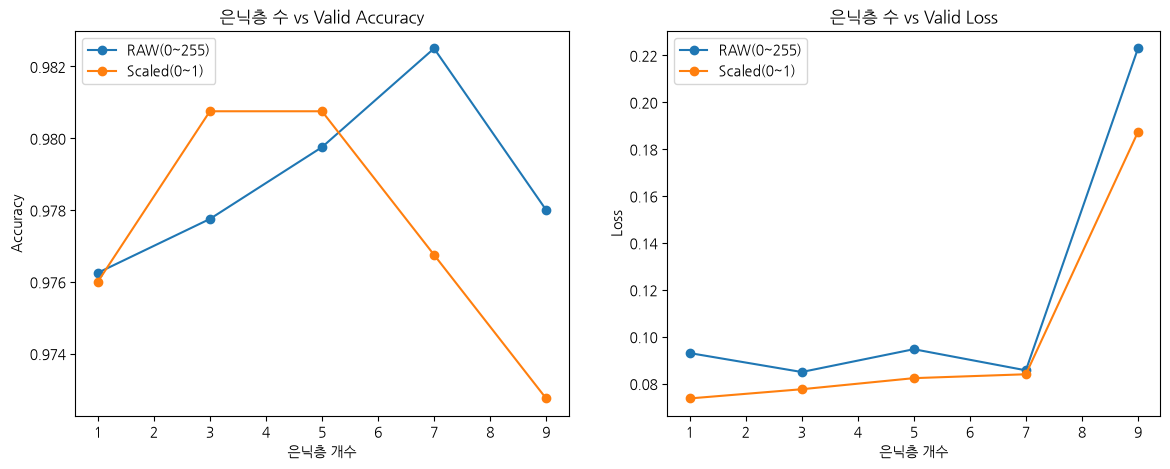

In [16]:
summary = pd.DataFrame([
    {'층 수': n_layers, '스케일링': scale_label,
     'Valid ACC': res['final_valid_acc'], 'Valid LOSS': res['final_valid_loss']}
    for (n_layers, scale_label), res in results.items()
]).sort_values(['스케일링', '층 수'])

display(summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for scale_label in scale_options:
    sub = summary[summary['스케일링'] == scale_label]
    axes[0].plot(sub['층 수'], sub['Valid ACC'], marker='o', label=scale_label)
    axes[1].plot(sub['층 수'], sub['Valid LOSS'], marker='o', label=scale_label)

axes[0].set_title('은닉층 수 vs Valid Accuracy')
axes[0].set_xlabel('은닉층 개수'); axes[0].set_ylabel('Accuracy'); axes[0].legend()

axes[1].set_title('은닉층 수 vs Valid Loss')
axes[1].set_xlabel('은닉층 개수'); axes[1].set_ylabel('Loss'); axes[1].legend()

plt.show()